In [1]:
import pandas as pd

df = pd.read_csv("../data/student_stress_dataset.csv")
# Check correlation with academic performance
corr = df.corr()["academic_performance"].sort_values(ascending=False)

print(corr)

academic_performance            1.000000
sleep_quality                   0.671326
teacher_student_relationship    0.669469
safety                          0.642846
basic_needs                     0.639387
self_esteem                     0.639045
social_support                  0.567501
living_conditions               0.507221
blood_pressure                 -0.262785
breathing_problem              -0.507251
noise_level                    -0.513730
study_load                     -0.520417
peer_pressure                  -0.562948
mental_health_history          -0.586193
extracurricular_activities     -0.588612
headache                       -0.622059
depression                     -0.633174
future_career_concerns         -0.643805
anxiety_level                  -0.649601
bullying                       -0.666229
stress_level                   -0.720922
Name: academic_performance, dtype: float64


Dataset Shape: (1100, 21)
   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0                  3

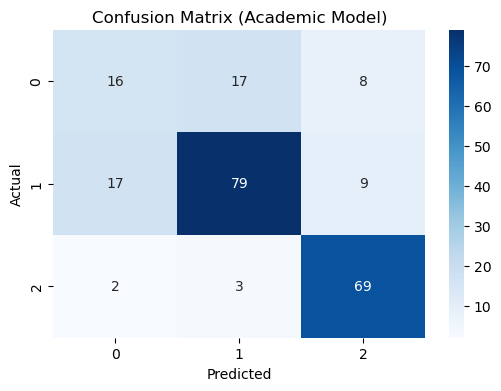

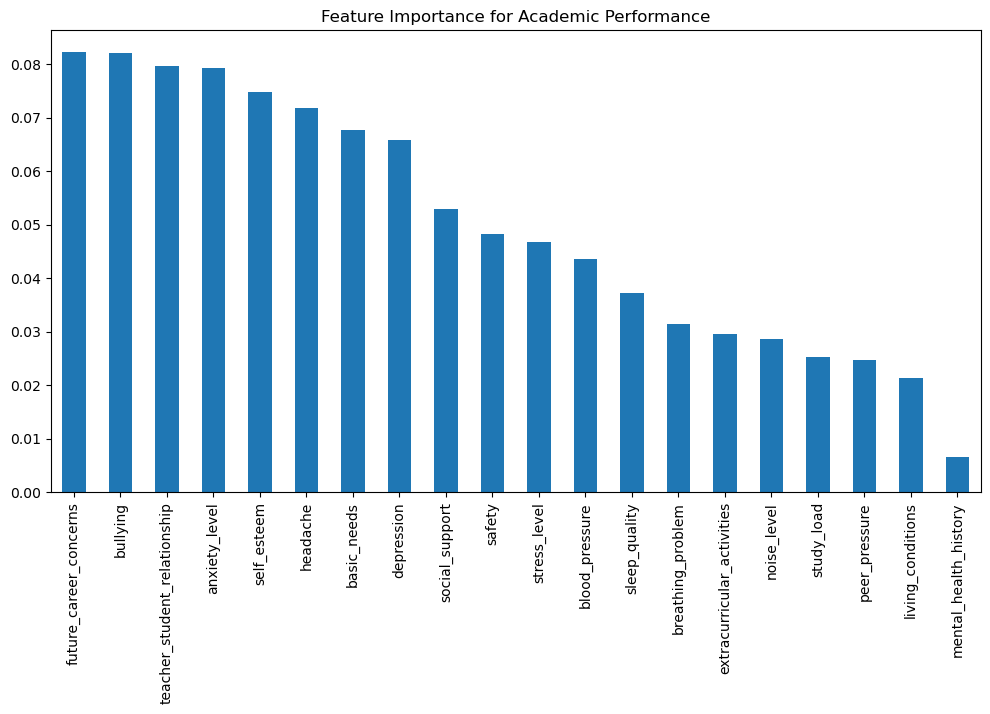


Logistic Regression selected as academic model

Academic model saved successfully


In [3]:
# ===============================
# Academic Performance Prediction Model
# ===============================

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


# 2️⃣ Load dataset
df = pd.read_csv("../data/student_stress_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# 3️⃣ Convert academic_performance into categories
# 0–1 → Low
# 2–3 → Medium
# 4–5 → High

def categorize_performance(x):
    if x <= 1:
        return 0   # Low
    elif x <= 3:
        return 1   # Medium
    else:
        return 2   # High

df["academic_category"] = df["academic_performance"].apply(categorize_performance)

print("\nAcademic category distribution:")
print(df["academic_category"].value_counts())


# 4️⃣ Correlation analysis
corr = df.corr()["academic_performance"].sort_values(ascending=False)

print("\nCorrelation with Academic Performance:")
print(corr)


# 5️⃣ Define features and target
X_academic = df.drop(["academic_performance", "academic_category"], axis=1)

y_academic = df["academic_category"]

print("\nFeature shape:", X_academic.shape)
print("Target shape:", y_academic.shape)


# 6️⃣ Train / Test split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_academic,
    y_academic,
    test_size=0.2,
    random_state=42
)

print("\nTrain size:", X_train_a.shape)
print("Test size:", X_test_a.shape)


# ===============================
# 7️⃣ Logistic Regression Model
# ===============================

log_model_academic = LogisticRegression(max_iter=3000)

log_model_academic.fit(X_train_a, y_train_a)

y_pred_log = log_model_academic.predict(X_test_a)

log_accuracy = accuracy_score(y_test_a, y_pred_log)

print("\nLogistic Regression Accuracy:", log_accuracy)

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_a, y_pred_log))


# ===============================
# 8️⃣ Random Forest Model
# ===============================

rf_model_academic = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model_academic.fit(X_train_a, y_train_a)

y_pred_rf = rf_model_academic.predict(X_test_a)

rf_accuracy = accuracy_score(y_test_a, y_pred_rf)

print("\nRandom Forest Accuracy:", rf_accuracy)

print("\nClassification Report (Random Forest):")
print(classification_report(y_test_a, y_pred_rf))


# ===============================
# 9️⃣ Confusion Matrix
# ===============================

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test_a, y_pred_rf),
    annot=True,
    cmap="Blues"
)

plt.title("Confusion Matrix (Academic Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ===============================
# 🔟 Feature Importance
# ===============================

importance_academic = pd.Series(
    rf_model_academic.feature_importances_,
    index=X_academic.columns
)

plt.figure(figsize=(12,6))

importance_academic.sort_values(ascending=False).plot(kind="bar")

plt.title("Feature Importance for Academic Performance")

plt.show()


# ===============================
# 1️⃣1️⃣ Select Best Model
# ===============================

if rf_accuracy > log_accuracy:
    best_academic_model = rf_model_academic
    print("\nRandom Forest selected as academic model")
else:
    best_academic_model = log_model_academic
    print("\nLogistic Regression selected as academic model")


# ===============================
# 1️⃣2️⃣ Save Model
# ===============================

joblib.dump(best_academic_model, "../academic_model.pkl")

joblib.dump(X_academic.columns.tolist(), "../academic_feature_columns.pkl")

print("\nAcademic model saved successfully")